# 1. Library

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import re
import matplotlib.pyplot as plt

# 2. Loading Text Corpus


In [2]:
corpus = '''
The sun rose above the hills and painted the sky with shades of orange and gold.
Birds sang from the trees as the morning breeze moved gently through the valley.
People began their daily routines, walking to work, opening shops, and greeting their neighbors.
A young student carried a backpack filled with books and dreams for the future.
The city grew busy as cars moved along the roads and conversations filled the air.
In the afternoon, clouds gathered across the horizon and brought a light rain.
Children laughed and played in the puddles while families watched from their windows.
As evening arrived, the streets became quieter and the lights of the town began to shine.
The moon appeared above the rooftops and illuminated the peaceful night.
Stars filled the sky, reminding everyone of the vast universe beyond the earth.
The next morning brought new opportunities, new challenges, and new stories to tell.

Every day offered a chance to learn, grow, and create something meaningful.
'''
print(corpus)


The sun rose above the hills and painted the sky with shades of orange and gold.
Birds sang from the trees as the morning breeze moved gently through the valley.
People began their daily routines, walking to work, opening shops, and greeting their neighbors.
A young student carried a backpack filled with books and dreams for the future.
The city grew busy as cars moved along the roads and conversations filled the air.
In the afternoon, clouds gathered across the horizon and brought a light rain.
Children laughed and played in the puddles while families watched from their windows.
As evening arrived, the streets became quieter and the lights of the town began to shine.
The moon appeared above the rooftops and illuminated the peaceful night.
Stars filled the sky, reminding everyone of the vast universe beyond the earth.
The next morning brought new opportunities, new challenges, and new stories to tell.

Every day offered a chance to learn, grow, and create something meaningful.



# 3. Cleaning
- In this cell i've change the letters to lower case
- Removed extra spaces

In [3]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

lines = [clean_text(l) for l in corpus.strip().split("\n") if l.strip()]
corpus = "\n".join(lines)

print("Cleaned corpus:\n")
print(corpus)

Cleaned corpus:

the sun rose above the hills and painted the sky with shades of orange and gold
birds sang from the trees as the morning breeze moved gently through the valley
people began their daily routines walking to work opening shops and greeting their neighbors
a young student carried a backpack filled with books and dreams for the future
the city grew busy as cars moved along the roads and conversations filled the air
in the afternoon clouds gathered across the horizon and brought a light rain
children laughed and played in the puddles while families watched from their windows
as evening arrived the streets became quieter and the lights of the town began to shine
the moon appeared above the rooftops and illuminated the peaceful night
stars filled the sky reminding everyone of the vast universe beyond the earth
the next morning brought new opportunities new challenges and new stories to tell
every day offered a chance to learn grow and create something meaningful


# 4. Tokenization & Sequence Creation

In [4]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 108
X shape: (152, 15)
y shape: (152,)


# 5. Model Creation

# 5.1: Vanilla RNN

In [5]:
rnn_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    SimpleRNN(64),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])
rnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

# 5.2: LSTM

In [6]:
lstm_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    LSTM(64),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])
lstm_model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

# 5.3: GRU

In [7]:
gru_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    GRU(64),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

# 5.4 Model Traning
  
- Epochs: 100      
- Optimizer: Adam

In [8]:
rnn_history = rnn_model.fit(X, y, epochs=100, verbose=0)
print("Vanilla RNN training completed")

lstm_history = lstm_model.fit(X, y, epochs=100, verbose=0)
print("LSTM training completed")

gru_history = gru_model.fit(X, y, epochs=100, verbose=0)
print("GRU training completed")

Vanilla RNN training completed
LSTM training completed
GRU training completed


# 5.5 All Model Losses

In [9]:
print(f"Model loss  RNN: {rnn_history.history['loss'][-1]:.4f} "
      f"LSTM: {lstm_history.history['loss'][-1]:.4f} "
      f"GRU: {gru_history.history['loss'][-1]:.4f}")

Model loss  RNN: 0.3709 LSTM: 1.6974 GRU: 0.6515


## 6. Optimization Trajectory

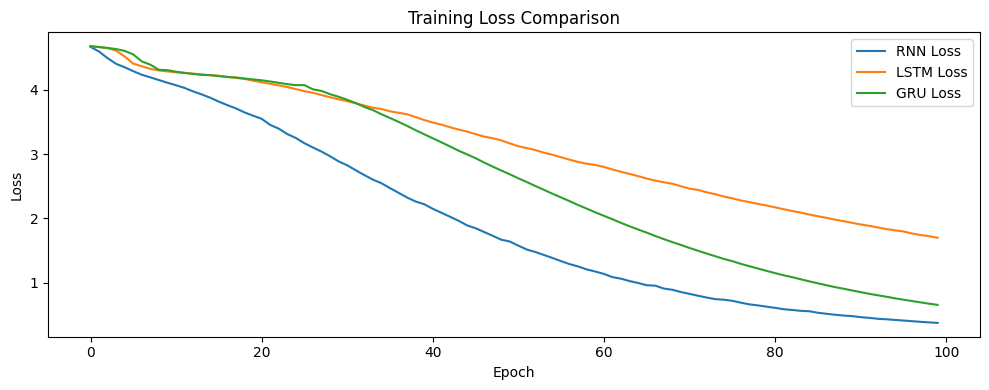

In [10]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN Loss')
plt.plot(lstm_history.history['loss'], label='LSTM Loss')
plt.plot(gru_history.history['loss'], label='GRU Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.tight_layout();
plt.show()

**Insights:**
- Simple RNN worked better with minimum loss compared to LSTM and GPU becase the Text corpus was small also when we go for long corpus it hurts the simple RNN but in this case corpus were small and it worked for simple RNN but not for LSTM.
- If we talk about GRU it worked better than LSTM as this is GRU is the updated version of LSTM. LSTM uses 3 gates while GRU only used 2 and simple but better arcitecture make it work better on both short and long corpus.


# 7. Text Generation Function with Internal selection Logic

In [11]:
def generate_text(model, seed_text, next_words=5):
    index_to_word = {idx: w for w, idx in tokenizer.word_index.items()}
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = index_to_word.get(predicted, "")
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

## 7.1 Generating Text Samples

In [12]:
seed_text = "A young student carried"
print("Seed Text:", seed_text)

print("\nRNN :", generate_text(rnn_model, seed_text, 5))
print("LSTM:", generate_text(lstm_model, seed_text, 5))
print("GRU :", generate_text(gru_model, seed_text, 5))

Seed Text: A young student carried

RNN : A young student carried a backpack filled with books
LSTM: A young student carried a a a books and
GRU : A young student carried a backpack filled with books


- RNN and GRU generate same results it clearly states that both of these model works on better on small corpus
- Comparitively LSTM didn't performed well as it works better on long corpus also it has the complex architecture.
- GRU also worked well because it is the updated version of LSTM and only 2 gates and simple architecture

# 9. Model
- Dimension: 64
- Epoch: 200
- Hidden Layers: 128

In [13]:
Embed_Dim = 64
Hidden = 128

rnn_model2 = Sequential([
    Embedding(total_words, Embed_Dim, input_length=max_len - 1),
    SimpleRNN(Hidden),
    Dense(total_words, activation='softmax')
])

lstm_model2 = Sequential([
    Embedding(total_words, Embed_Dim, input_length=max_len - 1),
    LSTM(Hidden),
    Dense(total_words, activation='softmax')
])

gru_model2 = Sequential([
    Embedding(total_words, Embed_Dim, input_length=max_len - 1),
    GRU(Hidden),
    Dense(total_words, activation='softmax')
])

rnn_model2.compile(loss='sparse_categorical_crossentropy',
          optimizer='adam', metrics=['accuracy'])

lstm_model2.compile(loss='sparse_categorical_crossentropy',
          optimizer='adam', metrics=['accuracy'])

gru_model2.compile(loss='sparse_categorical_crossentropy',
          optimizer='adam', metrics=['accuracy'])

rnn_model2.summary()
lstm_model2.summary()
gru_model2.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

...

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

# 9.2 Model Traning

In [14]:
Epochs = 200

rnn_history2  = rnn_model2.fit(X,  y, epochs=Epochs, verbose=0)

lstm_history2 = lstm_model2.fit(X, y, epochs=Epochs, verbose=0)

gru_history2  = gru_model2.fit(X,  y, epochs=Epochs, verbose=0)

print(f"\nFinal loss after 200 epochs:  "
      f"RNN: {rnn_history2.history['loss'][-1]:.4f} "
      f"LSTM: {lstm_history2.history['loss'][-1]:.4f} "
      f"GRU: {gru_history2.history['loss'][-1]:.4f}")


Final loss after 200 epochs:  RNN: 0.0487 LSTM: 0.0936 GRU: 0.0487


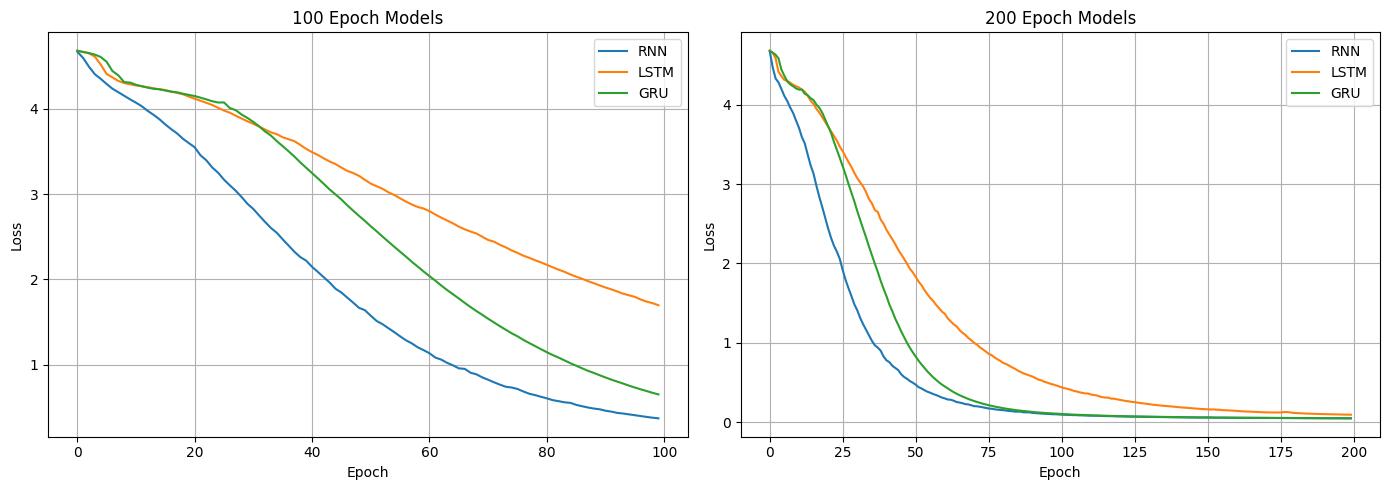

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(14,5))

# 100 epochs
ax[0].plot(rnn_history.history['loss'], label='RNN')
ax[0].plot(lstm_history.history['loss'], label='LSTM')
ax[0].plot(gru_history.history['loss'], label='GRU')
ax[0].set_title('100 Epoch Models')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')
ax[0].legend()
ax[0].grid(True)

# 200 epochs
ax[1].plot(rnn_history2.history['loss'], label='RNN')
ax[1].plot(lstm_history2.history['loss'], label='LSTM')
ax[1].plot(gru_history2.history['loss'], label='GRU')
ax[1].set_title('200 Epoch Models')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Loss')
ax[1].legend()
ax[1].grid(True)

plt.tight_layout()
plt.show()

# 9.2 Output 10 words

**Insights after traning new models**
> After scaling up when i increate the hidden layer, Dimension and Epochs all three models reached very low loss and generate same sentence.
This clearly shows that the models successfully learned the corpu.

In [16]:
seed_text = "The sun rose above the hills"
print("Seed Text:", seed_text)

print("\nRNN :", generate_text(rnn_model2, seed_text, 10))
print("LSTM:", generate_text(lstm_model2, seed_text, 10))
print("GRU :", generate_text(gru_model2, seed_text, 10))

Seed Text: The sun rose above the hills

RNN : The sun rose above the hills and painted the sky with shades of orange and gold
LSTM: The sun rose above the hills and painted the sky with shades of orange and gold
GRU : The sun rose above the hills and painted the sky with shades of orange and gold


***All 3 model worked well on small corpus when better parameter are used along with more epcohs to train models.***

**CONCLUSION:**
> - Gated architectures (LSTM, GRU) are not automatically better on short corpors. If we go for long corps these models would work better as they also maintain the Long Term memory
> - Embedding dimension, hidden size and Epochs made the models work better models return best losses compare to previous models
> - When we use better Embedding dimension, hidden size and Epochs the generate text and loss difference of all 3 models were almost negligible.